# Eksperimen - Heart Disease Dataset
Notebook ini melakukan data loading, EDA, dan preprocessing sesuai template MSML.

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 50)


## 2. Data Loading

In [2]:
df = pd.read_csv('../namadataset_raw/heart_raw.csv')
print('Shape:', df.shape)
df.head()


Shape: (920, 26)


,age,trestbps,chol,thalch,oldpeak,ca,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect,target
0,1.007386,0.705176,0.303643,0.489727,1.368109,-0.361400,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
1,1.432034,1.518569,0.789967,-1.181478,0.611589,4.411152,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1
2,1.432034,-0.650479,0.266939,-0.345875,1.651804,2.820301,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1
3,-1.752828,-0.108217,0.459634,1.961979,2.502889,-0.361400,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
4,-1.328180,-0.108217,0.037541,1.365120,0.517024,-0.361400,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       920 non-null    float64
 1   trestbps                  920 non-null    float64
 2   chol                      920 non-null    float64
 3   thalch                    920 non-null    float64
 4   oldpeak                   920 non-null    float64
 5   ca                        920 non-null    float64
 6   sex_Female                920 non-null    float64
 7   sex_Male                  920 non-null    float64
 8   cp_asymptomatic           920 non-null    float64
 9   cp_atypical angina        920 non-null    float64
 10  cp_non-anginal            920 non-null    float64
 11  cp_typical angina         920 non-null    float64
 12  fbs_False                 920 non-null    float64
 13  fbs_True                  920 non-null    float64
 14  restecg_lv hypertroph

In [4]:
df.describe()


,age,trestbps,chol,thalch,oldpeak,ca,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect,target
count,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,6.178632e-17,-7.723291e-18,-9.267949e-17,-4.325043e-16,-7.723291e-18,6.178632e-17,0.210870,0.789130,0.539130,0.189130,0.221739,0.050000,0.850000,0.150000,0.204348,0.601087,0.194565,0.633696,0.366304,0.068478,0.710870,0.220652,0.050000,0.741304,0.208696,0.553261
std,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,1.000544e+00,0.408148,0.408148,0.498738,0.391825,0.415642,0.218063,0.357266,0.357266,0.403444,0.489941,0.396081,0.482056,0.482056,0.252702,0.453605,0.414912,0.218063,0.438156,0.406597,0.497426
min,-2.708286e+00,-7.157623e+00,-1.834346e+00,-3.091427e+00,-3.265577e+00,-3.613997e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-6.912073e-01,-6.504787e-01,-2.033264e-01,-7.039908e-01,-8.068863e-01,-3.613997e-01,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.192709e-02,-1.082166e-01,2.118840e-01,9.182113e-02,-3.340612e-01,-3.613997e-01,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000
75%,6.888994e-01,4.340454e-01,6.156245e-01,7.284707e-01,6.115890e-01,-3.613997e-01,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000
max,2.493654e+00,3.687618e+00,3.698734e+00,2.558838e+00,5.056145e+00,4.411152e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
print('Jumlah missing value per kolom:')
print(df.isnull().sum())
print('\nJumlah duplikat baris:', df.duplicated().sum())


Jumlah missing value per kolom:
age                         0
trestbps                    0
chol                        0
thalch                      0
oldpeak                     0
ca                          0
sex_Female                  0
sex_Male                    0
cp_asymptomatic             0
cp_atypical angina          0
cp_non-anginal              0
cp_typical angina           0
fbs_False                   0
fbs_True                    0
restecg_lv hypertrophy      0
restecg_normal              0
restecg_st-t abnormality    0
exang_False                 0
exang_True                  0
slope_downsloping           0
slope_flat                  0
slope_upsloping             0
thal_fixed defect           0
thal_normal                 0
thal_reversable defect      0
target                      0
dtype: int64

Jumlah duplikat baris: 2


Distribusi target:
target
1    509
0    411
Name: count, dtype: int64


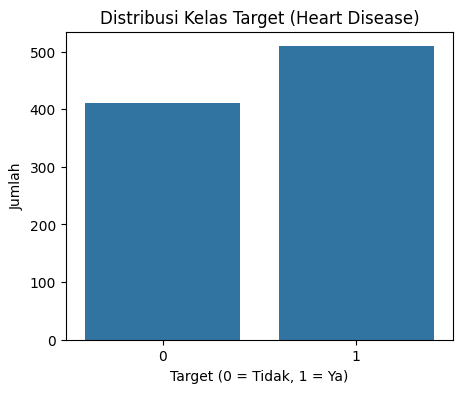

In [6]:
print('Distribusi target:')
print(df['target'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title('Distribusi Kelas Target (Heart Disease)')
plt.xlabel('Target (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.show()


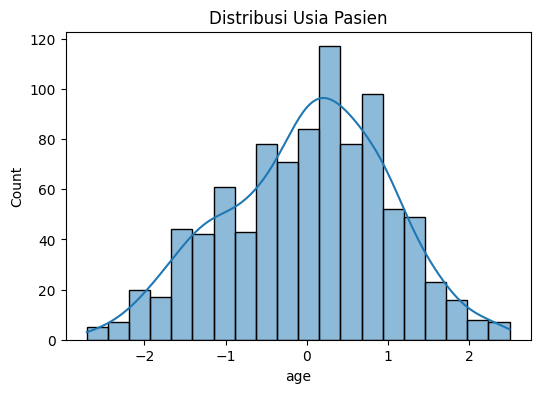

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True, bins=20)
plt.title('Distribusi Usia Pasien')
plt.show()


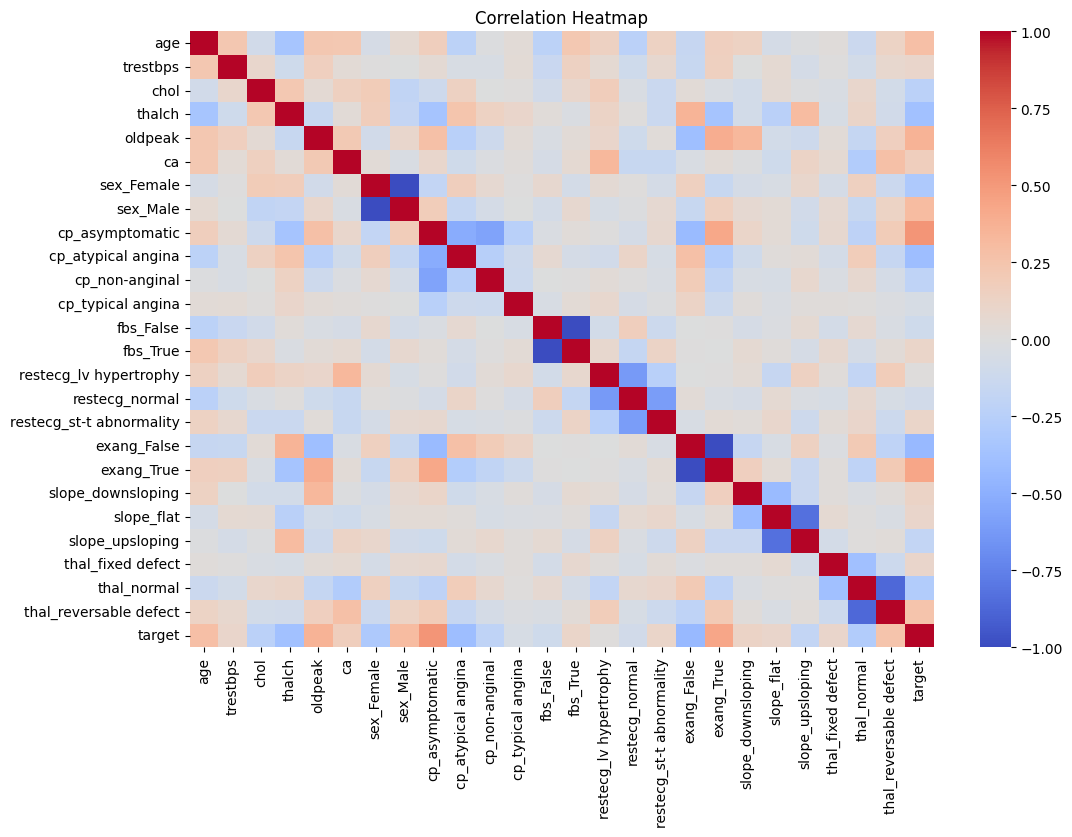

In [8]:
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


## 4. Data Preprocessing
Menghapus duplikat (jika ada), memisahkan fitur & target, membagi data train/test, dan melakukan scaling pada fitur numerik.

In [9]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print('Shape setelah drop duplikat:', df_clean.shape)

X = df_clean.drop(columns=['target'])
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print('X_train:', X_train_scaled.shape, '| X_test:', X_test_scaled.shape)


Shape setelah drop duplikat: (918, 26)
X_train: (734, 25) | X_test: (184, 25)


## 5. Simpan Hasil Preprocessing

In [10]:
train_out = X_train_scaled.copy()
train_out['target'] = y_train.values
test_out = X_test_scaled.copy()
test_out['target'] = y_test.values

full_out = pd.concat([train_out, test_out], axis=0).reset_index(drop=True)
full_out.to_csv('namadataset_preprocessing/heart_preprocessing.csv', index=False)
print('Tersimpan:', full_out.shape)
full_out.head()


Tersimpan: (918, 26)


,age,trestbps,chol,thalch,oldpeak,ca,sex_Female,sex_Male,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_False,fbs_True,restecg_lv hypertrophy,restecg_normal,restecg_st-t abnormality,exang_False,exang_True,slope_downsloping,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect,target
0,-0.275038,-0.676985,-1.824096,-0.429768,0.606406,-0.360883,1.909337,-1.909337,0.934050,-0.483336,-0.544812,-0.223767,0.41084,-0.41084,-0.51740,0.831411,-0.496165,-1.314772,1.314772,-0.258574,-1.533492,1.800771,-0.236886,0.607785,-0.525853,1
1,-1.346579,-0.676985,0.854985,1.276224,-0.809313,-0.360883,-0.523742,0.523742,-1.070607,2.068955,-0.544812,-0.223767,0.41084,-0.41084,-0.51740,0.831411,-0.496165,0.760588,-0.760588,-0.258574,0.652106,-0.555318,-0.236886,0.607785,-0.525853,0
2,0.689348,0.994790,0.518964,0.760459,1.644601,2.869464,1.909337,-1.909337,0.934050,-0.483336,-0.544812,-0.223767,0.41084,-0.41084,1.93274,-1.202775,-0.496165,0.760588,-0.760588,-0.258574,0.652106,-0.555318,-0.236886,-1.645318,1.901671,1
3,0.046424,-0.398356,0.137536,0.085997,-0.809313,-0.360883,-0.523742,0.523742,0.934050,-0.483336,-0.544812,-0.223767,0.41084,-0.41084,-0.51740,0.831411,-0.496165,0.760588,-0.760588,-0.258574,0.652106,-0.555318,-0.236886,0.607785,-0.525853,1
4,0.475040,-1.791502,0.301005,0.720785,-0.714932,1.254290,-0.523742,0.523742,0.934050,-0.483336,-0.544812,-0.223767,0.41084,-0.41084,-0.51740,0.831411,-0.496165,0.760588,-0.760588,-0.258574,-1.533492,1.800771,-0.236886,-1.645318,1.901671,1
